In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
print("Libraries imported!")

Libraries imported!


In [2]:
df = pd.read_csv('heart_cleveland_upload.csv')
print(df.shape)
df.head()

(297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [3]:
print(df.isnull().sum())
print("Total missing:", df.isnull().sum().sum())

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64
Total missing: 0


In [6]:
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric)

for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print("Missing after cleaning:", df.isnull().sum().sum())

Missing after cleaning: 0


In [9]:
df['condition'] = df['condition'].apply(lambda x: 1 if x > 0 else 0)
print(df['condition'].value_counts())

condition
0    160
1    137
Name: count, dtype: int64


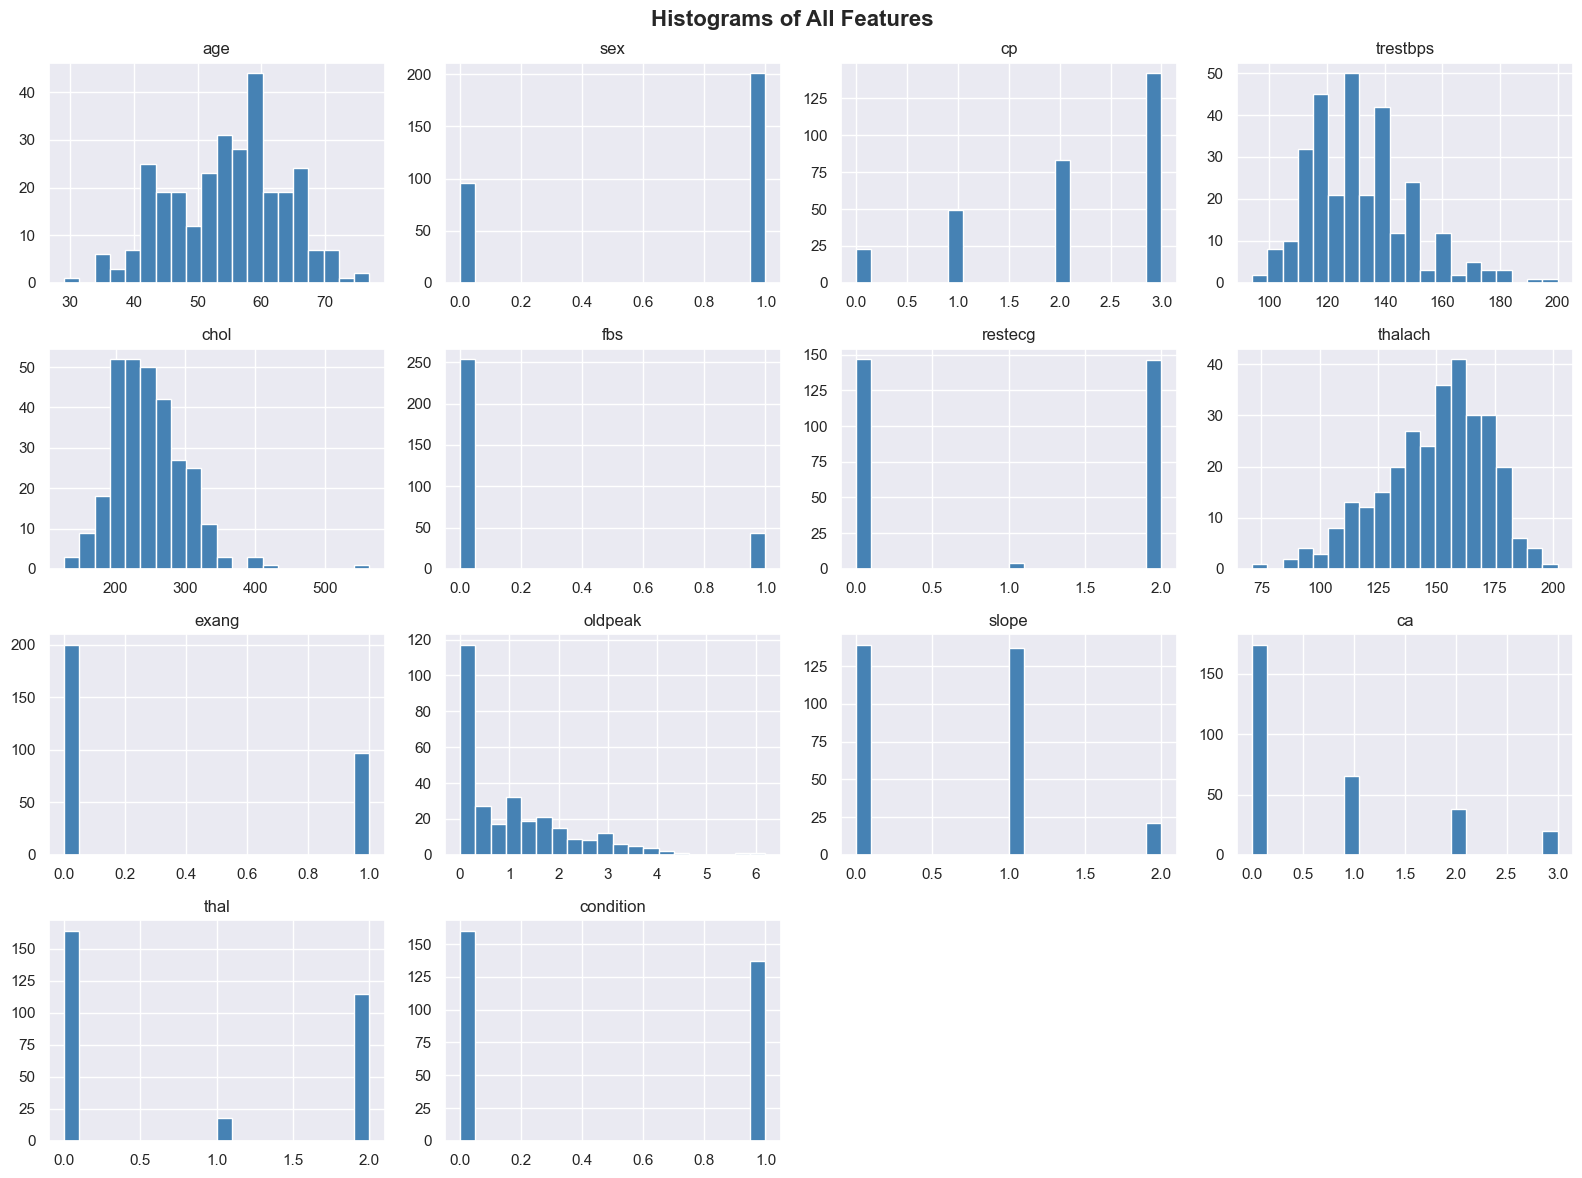

In [10]:
df.hist(figsize=(16, 12), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Histograms of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

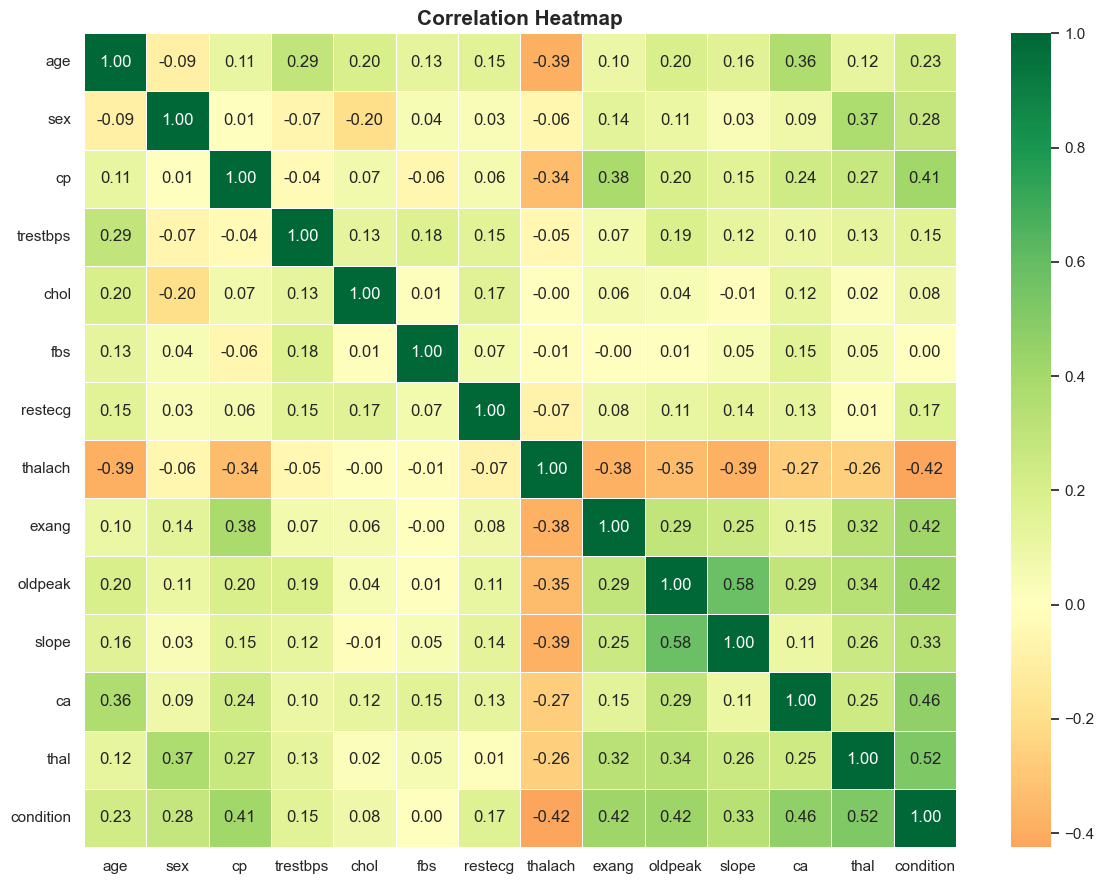

In [11]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [12]:
df.to_csv('heart_disease_cleaned.csv', index=False)
print("✅ Cleaned dataset save")

✅ Cleaned dataset save
